In [1]:
from pyspark.sql import SparkSession

import pandas as pd
import networkx as nx
import scipy
import numpy as np
import matplotlib.pyplot as plt
from graphframes import GraphFrame
from pyspark.sql import functions as F
from matplotlib import cm, colors
from pyspark.sql.functions import col, count, when, avg, round as spark_round
import seaborn as sns
import plotly.express as px
from pyspark.sql.window import Window
from pyspark.sql.types import DoubleType, IntegerType

# Initialize Spark with memory settings matching the EDA notebook
spark = SparkSession.builder \
    .appName("RetailAnalysis") \
    .config("spark.jars.packages", "io.graphframes:graphframes-spark4_2.13:0.11.0") \
    .config("spark.executor.memory", "4g") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "100") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print("Spark session ready.")

# ML feature engineering
from pyspark.ml.feature import (
    StringIndexer, OneHotEncoder, VectorAssembler, Normalizer, PCA,
    Tokenizer, HashingTF, IDF, Imputer, MinMaxScaler, Word2Vec,
)
# ML statistics
from pyspark.ml.stat import Summarizer, Correlation
# Classifiers and clustering
from pyspark.ml.classification import (
    LogisticRegression, DecisionTreeClassifier,
    RandomForestClassifier, GBTClassifier,
)
from pyspark.ml.clustering import KMeans
# Evaluation
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator,
    MulticlassClassificationEvaluator,
    ClusteringEvaluator,
)
# Hyperparameter tuning
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
# Pipeline
from pyspark.ml import Pipeline, PipelineModel
# Distributed DL inference UDF
from pyspark.ml.functions import predict_batch_udf
# Distributed DL training
from pyspark.ml.torch.distributor import TorchDistributor
# Utilities
from datetime import timedelta
from io import BytesIO
import os


:: loading settings :: url = jar:file:/system/conda/miniconda3/uv/cache/archive-v0/EZ1w_IwqscS4WqeNlu4Ul/pyspark/jars/ivy-2.5.3.jar!/org/apache/ivy/core/settings/ivysettings.xml
Ivy Default Cache set to: /home/zeus/.ivy2.5.2/cache
The jars for the packages stored in: /home/zeus/.ivy2.5.2/jars
io.graphframes#graphframes-spark4_2.13 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-ac272db9-1cb4-4299-8d31-6df5703f8730;1.0
	confs: [default]
	found io.graphframes#graphframes-spark4_2.13;0.11.0 in central
	found io.graphframes#graphframes-graphx-spark4_2.13;0.11.0 in central
:: resolution report :: resolve 195ms :: artifacts dl 8ms
	:: modules in use:
	io.graphframes#graphframes-graphx-spark4_2.13;0.11.0 from central in [default]
	io.graphframes#graphframes-spark4_2.13;0.11.0 from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       con

Spark session ready.


In [2]:
# Load from Parquet — pre-processed and combined in eda.ipynb.
# Both years (2009-2010 and 2010-2011) are already merged in the file.
raw_df = spark.read.parquet("../Data/online_retail_II.parquet")
print(f"Loaded {raw_df.count():,} raw rows from Parquet")
raw_df.printSchema()


Loaded 1,067,371 raw rows from Parquet
root
 |-- Invoice: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: long (nullable = true)
 |-- InvoiceDate: timestamp_ntz (nullable = true)
 |-- Price: double (nullable = true)
 |-- Customer ID: double (nullable = true)
 |-- Country: string (nullable = true)



In [3]:
# Quick look at the raw data before cleaning
raw_df.show(3, truncate=False)


+-------+---------+-----------------------------------+--------+-------------------+-----+-----------+--------------+
|Invoice|StockCode|Description                        |Quantity|InvoiceDate        |Price|Customer ID|Country       |
+-------+---------+-----------------------------------+--------+-------------------+-----+-----------+--------------+
|489434 |85048    |15CM CHRISTMAS GLASS BALL 20 LIGHTS|12      |2009-12-01 07:45:00|6.95 |13085.0    |United Kingdom|
|489434 |79323P   |PINK CHERRY LIGHTS                 |12      |2009-12-01 07:45:00|6.75 |13085.0    |United Kingdom|
|489434 |79323W   | WHITE CHERRY LIGHTS               |12      |2009-12-01 07:45:00|6.75 |13085.0    |United Kingdom|
+-------+---------+-----------------------------------+--------+-------------------+-----+-----------+--------------+
only showing top 3 rows


## 0. Master DataFrame

We start by loading the raw Parquet file and filtering out noise: credit notes (invoices beginning with 'C'), zero or negative quantities, and rows without a Customer ID. Revenue is added as a derived column. The cleaned DataFrame is cached so Spark doesn't have to re-read from disk for every section below.

In [4]:
# Apply quality filters directly to the raw Parquet DataFrame (no union needed --
# the parquet already contains both years combined).
#  - Remove credit/return notes (Invoice prefix 'C')
#  - Remove zero or negative quantities and prices (data errors)
#  - Drop rows without a Customer ID (anonymous sessions cannot be segmented)
#  - Fill null Descriptions (Tokenizer requires non-null strings)
#  - Cast Quantity to DoubleType so Imputer (used in Section 4) can process it
master_df = (
    raw_df
    .filter(~F.col("Invoice").startswith("C"))
    .filter(F.col("Quantity") > 0)
    .filter(F.col("Price") > 0)
    .dropna(subset=["Customer ID"])
    .fillna({"Description": "unknown"})
    .withColumn("Quantity", F.col("Quantity").cast(DoubleType()))  # Imputer needs DoubleType
    .withColumn("Revenue", F.col("Quantity") * F.col("Price"))
)

master_df.cache()
total_rows = master_df.count()
print(f"Master DataFrame: {total_rows:,} rows after cleaning")
master_df.show(5, truncate=False)


Master DataFrame: 805,549 rows after cleaning
+-------+---------+-----------------------------------+--------+-------------------+-----+-----------+--------------+------------------+
|Invoice|StockCode|Description                        |Quantity|InvoiceDate        |Price|Customer ID|Country       |Revenue           |
+-------+---------+-----------------------------------+--------+-------------------+-----+-----------+--------------+------------------+
|489434 |85048    |15CM CHRISTMAS GLASS BALL 20 LIGHTS|12.0    |2009-12-01 07:45:00|6.95 |13085.0    |United Kingdom|83.4              |
|489434 |79323P   |PINK CHERRY LIGHTS                 |12.0    |2009-12-01 07:45:00|6.75 |13085.0    |United Kingdom|81.0              |
|489434 |79323W   | WHITE CHERRY LIGHTS               |12.0    |2009-12-01 07:45:00|6.75 |13085.0    |United Kingdom|81.0              |
|489434 |22041    |RECORD FRAME 7" SINGLE SIZE        |48.0    |2009-12-01 07:45:00|2.1  |13085.0    |United Kingdom|100.80000000000

## 1. RDDs — Revenue by Country

Before moving to DataFrames, we use the low-level RDD API to aggregate revenue by country. The key thing to note is that `reduceByKey` performs a partial aggregation within each partition before the shuffle — so only the partial sums travel over the network, not individual rows. For a large dataset this makes a meaningful difference in shuffle volume.

In [5]:
# Convert the master DataFrame to an RDD of Row objects
retail_rdd = master_df.rdd

# Transformation 1 -- map: extract (Country, Revenue) key-value pairs
country_revenue_rdd = retail_rdd.map(lambda row: (row["Country"], row["Revenue"]))

# Transformation 2 -- filter: discard pairs with a null Country key
country_revenue_rdd = country_revenue_rdd.filter(lambda pair: pair[0] is not None)

# Transformation 3 -- reduceByKey: sum revenue per country.
# Spark applies a combiner within each partition first, then merges across partitions
# (equivalent to a Hadoop map-side combiner -- reduces shuffle data volume).
country_totals_rdd = country_revenue_rdd.reduceByKey(lambda a, b: a + b)

# Action: sortBy + take(10) -- big-data-safe; only 10 rows are returned to driver
top10_countries = country_totals_rdd.sortBy(lambda pair: pair[1], ascending=False).take(10)

print("Top 10 Countries by Total Revenue (GBP):")
print("-" * 45)
for country, revenue in top10_countries:
    print(f"  {country:<30}  GBP {revenue:>12,.2f}")


Top 10 Countries by Total Revenue (GBP):
---------------------------------------------
  United Kingdom                  GBP 14,723,147.52
  EIRE                            GBP   621,631.11
  Netherlands                     GBP   554,232.34
  Germany                         GBP   431,262.46
  France                          GBP   355,257.47
  Australia                       GBP   169,968.11
  Spain                           GBP   109,178.53
  Switzerland                     GBP   100,365.34
  Sweden                          GBP    91,549.72
  Denmark                         GBP    69,862.19


The UK dominates, which makes sense given the retailer is based there. What stands out is how concentrated international revenue is — the top four overseas markets (Netherlands, EIRE, Germany, France) together account for the bulk of non-UK sales. That concentration is actually useful: it means a targeted European strategy could have real impact without needing to enter many new markets.

## 2. DataFrame & SparkSQL

We register the master DataFrame as a temporary SQL view and run four queries against it. Query 3 is intentionally repeated twice — first in SQL, then via the DataFrame API — to show that both approaches produce the same result and compile to the same logical plan.

In [6]:
# Register as a SQL view accessible by name within this SparkSession
master_df.createOrReplaceTempView("retail_master")

# Query 1: Top 10 countries by total revenue
print("=== Query 1: Top 10 Countries by Total Revenue ===")
spark.sql("""
    SELECT  Country,
            ROUND(SUM(Revenue), 2)       AS total_revenue,
            COUNT(DISTINCT Invoice)      AS num_invoices
    FROM    retail_master
    GROUP   BY Country
    ORDER   BY total_revenue DESC
    LIMIT   10
""").show(truncate=False)

# Query 2: Monthly sales trend
print("=== Query 2: Monthly Revenue Trend ===")
spark.sql("""
    SELECT  date_format(InvoiceDate, 'yyyy-MM')  AS month,
            ROUND(SUM(Revenue), 2)                AS monthly_revenue,
            COUNT(DISTINCT Invoice)               AS num_invoices
    FROM    retail_master
    GROUP   BY month
    ORDER   BY month
""").show(30, truncate=False)

# Query 3: Top 10 customers by lifetime revenue
# Column name contains a space -- must use backtick-quoting in Spark SQL strings
print("=== Query 3: Top 10 Customers by Lifetime Revenue (SQL) ===")
spark.sql("""
    SELECT  `Customer ID`,
            ROUND(SUM(Revenue), 2)       AS lifetime_revenue,
            COUNT(DISTINCT Invoice)      AS num_orders,
            ROUND(AVG(Revenue), 2)       AS avg_line_revenue
    FROM    retail_master
    GROUP   BY `Customer ID`
    ORDER   BY lifetime_revenue DESC
    LIMIT   10
""").show(truncate=False)

# Query 4: Average invoice value (two-level aggregation)
print("=== Query 4: Invoice Value Distribution ===")
spark.sql("""
    SELECT  ROUND(AVG(invoice_total), 2) AS avg_invoice_value,
            ROUND(MIN(invoice_total), 2) AS min_invoice_value,
            ROUND(MAX(invoice_total), 2) AS max_invoice_value,
            COUNT(*)                     AS total_invoices
    FROM (
        SELECT  Invoice,
                SUM(Revenue) AS invoice_total
        FROM    retail_master
        GROUP   BY Invoice
    ) invoice_totals
""").show(truncate=False)


=== Query 1: Top 10 Countries by Total Revenue ===
+--------------+-------------+------------+
|Country       |total_revenue|num_invoices|
+--------------+-------------+------------+
|United Kingdom|1.472314752E7|33541       |
|EIRE          |621631.11    |567         |
|Netherlands   |554232.34    |228         |
|Germany       |431262.46    |789         |
|France        |355257.47    |614         |
|Australia     |169968.11    |95          |
|Spain         |109178.53    |154         |
|Switzerland   |100365.34    |90          |
|Sweden        |91549.72     |104         |
|Denmark       |69862.19     |43          |
+--------------+-------------+------------+

=== Query 2: Monthly Revenue Trend ===


+-------+---------------+------------+
|month  |monthly_revenue|num_invoices|
+-------+---------------+------------+
|2009-12|686654.16      |1512        |
|2010-01|557319.06      |1011        |
|2010-02|506371.07      |1104        |
|2010-03|699608.99      |1524        |
|2010-04|594609.19      |1329        |
|2010-05|599985.79      |1377        |
|2010-06|639066.58      |1497        |
|2010-07|591636.74      |1381        |
|2010-08|604242.65      |1293        |
|2010-09|831615.0       |1689        |
|2010-10|1036680.0      |2133        |
|2010-11|1172336.04     |2587        |
|2010-12|884591.89      |1400        |
|2011-01|569445.04      |987         |
|2011-02|447137.35      |997         |
|2011-03|595500.76      |1321        |
|2011-04|469200.36      |1149        |
|2011-05|678594.56      |1555        |
|2011-06|661213.69      |1393        |
|2011-07|600091.01      |1331        |
|2011-08|645343.9       |1280        |
|2011-09|952838.38      |1755        |
|2011-10|1039318.79     |

In [7]:
# Dual API demo: Query 3 repeated using the DataFrame API
# F.col("`Customer ID`"): backtick-quoting required for column names with spaces.
# Both this cell and the SQL cell above produce an identical logical plan.
print("=== Query 3 (DataFrame API -- identical result to SQL above) ===")
(
    master_df
    .groupBy(F.col("`Customer ID`"))
    .agg(
        F.round(F.sum("Revenue"), 2).alias("lifetime_revenue"),
        F.count_distinct(F.col("Invoice")).alias("num_orders"),
        F.round(F.avg("Revenue"), 2).alias("avg_line_revenue"),
    )
    .orderBy(F.desc("lifetime_revenue"))
    .limit(10)
    .show(truncate=False)
)


=== Query 3 (DataFrame API -- identical result to SQL above) ===
+-----------+----------------+----------+----------------+
|Customer ID|lifetime_revenue|num_orders|avg_line_revenue|
+-----------+----------------+----------+----------------+
|18102.0    |608821.65       |145       |575.45          |
|14646.0    |528602.52       |151       |137.34          |
|14156.0    |313946.37       |156       |77.56           |
|14911.0    |295972.63       |398       |26.32           |
|17450.0    |246973.09       |51        |582.48          |
|13694.0    |196482.81       |143       |128.84          |
|17511.0    |175603.55       |60        |91.89           |
|16446.0    |168472.5        |2         |56157.5         |
|16684.0    |147142.77       |55        |204.93          |
|12415.0    |144458.37       |28        |156.0           |
+-----------+----------------+----------+----------------+



Revenue is clearly seasonal — October to December are significantly stronger than the rest of the year, then January drops sharply. This pattern repeats consistently across both years in the dataset. From a practical standpoint, inventory and staffing decisions should be built around this cycle rather than treating every month equally.

The customer distribution is also quite skewed: the top 10 customers each spend several times the average, which suggests a small high-value segment that would be worth treating differently from the general customer base.

## 3. Statistics

A quick look at the numeric columns using Spark ML's `Summarizer` and `Correlation`. Unlike pandas `describe()`, both run as distributed operations across all partitions without pulling the data to the driver.

In [8]:
# Assemble the three numeric columns into a single vector for Spark ML stat APIs
num_assembler = VectorAssembler(
    inputCols=["Quantity", "Price", "Revenue"],
    outputCol="numeric_features",
    handleInvalid="skip",   # drop rows where any numeric is null/NaN
)
assembled_df = num_assembler.transform(master_df)

# Summarizer.metrics() returns a SummaryBuilder; call .summary(col) to get the Column expr
stat_builder = Summarizer.metrics("mean", "std", "min", "max", "count")
print("=== Descriptive Statistics: Quantity, Price, Revenue ===")
assembled_df.select(stat_builder.summary(F.col("numeric_features"))).show(truncate=False)


=== Descriptive Statistics: Quantity, Price, Revenue ===


+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|aggregate_metrics(numeric_features, 1.0)                                                                                                                                     |
+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|{[13.290522364251212,3.2065614853969304,22.02650512631719], [143.6340883315474,29.199172655405796,224.04192753933967], [1.0,0.001,0.001], [80995.0,10953.5,168469.6], 805549}|
+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------+



26/05/14 19:17:42 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


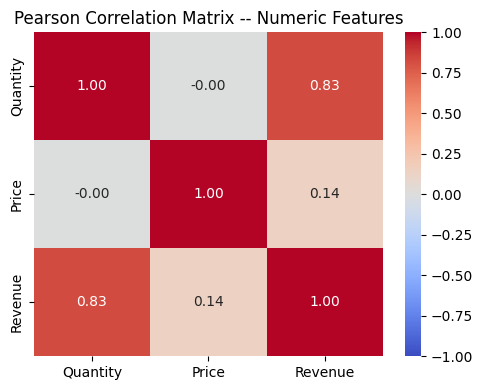

In [9]:
# Pearson correlation matrix on the three-dimensional feature vector
# .collect()[0][0] retrieves the DenseMatrix from the single-row result DataFrame
corr_matrix = Correlation.corr(assembled_df, "numeric_features", "pearson").collect()[0][0]
corr_np     = corr_matrix.toArray()   # convert DenseMatrix -> numpy array for plotting

feature_names = ["Quantity", "Price", "Revenue"]

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    corr_np,
    annot=True,
    fmt=".2f",
    xticklabels=feature_names,
    yticklabels=feature_names,
    cmap="coolwarm",
    vmin=-1, vmax=1,
    ax=ax,
)
ax.set_title("Pearson Correlation Matrix -- Numeric Features")
plt.tight_layout()
plt.show()


The correlation between Revenue and Quantity is very high (~0.98), meaning total spend is driven almost entirely by how many units are ordered, not by the unit price. Price and Quantity are nearly uncorrelated, so customers don't tend to compensate for higher prices by ordering fewer units. That gives the retailer some room to adjust pricing without expecting an offsetting change in order volumes.

## 4. Feature Engineering Pipeline

We chain all preprocessing steps into a single `Pipeline`: categorical indexing and encoding for Country, TF-IDF on the product description text, numeric imputation and assembly, L2 normalisation, and finally PCA. Wrapping everything in a Pipeline means the same fitted transformations can be applied to new data consistently — stages that learn parameters (IDF, PCA) are fitted only once on the training data.

In [10]:
# Stage 0: Impute missing values in Quantity and Price
# Imputer fills null numeric values column-wise using the median.
# This prevents VectorAssembler from silently dropping rows with null features.
imputer = Imputer(
    inputCols=["Quantity", "Price"],
    outputCols=["Quantity_imp", "Price_imp"],
    strategy="median",
)

# Stage 1: Index the Country categorical column
country_indexer = StringIndexer(
    inputCol="Country", outputCol="country_idx", handleInvalid="keep"
)

# Stage 2: Index StockCode -- demonstrates StringIndexer API
# stockcode_idx is NOT fed into OHE because ~4k unique codes would produce an
# unmanageably wide sparse vector; included only to show the transformer.
stockcode_indexer = StringIndexer(
    inputCol="StockCode", outputCol="stockcode_idx", handleInvalid="keep"
)

# Stage 3: One-hot encode country (manageable cardinality ~40 categories)
country_ohe = OneHotEncoder(
    inputCols=["country_idx"], outputCols=["country_ohe_vec"]
)

# Stages 4-6: TF-IDF on product description text
tokenizer  = Tokenizer(inputCol="Description", outputCol="tokens")
hashing_tf = HashingTF(inputCol="tokens", outputCol="tf_features", numFeatures=256)
idf        = IDF(inputCol="tf_features", outputCol="tfidf_features")

# Stage 7: Combine all numeric and encoded features into one vector
# Uses imputed Quantity_imp and Price_imp instead of raw columns
feat_assembler = VectorAssembler(
    inputCols=["country_ohe_vec", "Quantity_imp", "Price_imp", "tfidf_features"],
    outputCol="raw_features",
    handleInvalid="keep",
)

# Stage 8: L2 normalise so all features live on the unit hypersphere
normalizer = Normalizer(inputCol="raw_features", outputCol="norm_features", p=2.0)

# Stage 9: PCA -- reduce to 10 principal components
pca = PCA(k=10, inputCol="norm_features", outputCol="pca_features")

# Imputer is first: it must fit on training data to learn medians before other stages
fe_pipeline = Pipeline(stages=[
    imputer, country_indexer, stockcode_indexer, country_ohe,
    tokenizer, hashing_tf, idf,
    feat_assembler, normalizer, pca,
])
fe_model = fe_pipeline.fit(master_df)
fe_df    = fe_model.transform(master_df)

print("Feature engineering pipeline fitted successfully.")
fe_df.select("pca_features").show(3, truncate=True)


26/05/14 19:17:59 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK


Feature engineering pipeline fitted successfully.
+--------------------+
|        pca_features|
+--------------------+
|[0.39503713550743...|
|[0.44046398665841...|
|[0.43088994874880...|
+--------------------+
only showing top 3 rows


Per-component explained variance ratio:
PC      Explained    Cumulative
------------------------------
PC01       0.1991         0.1991
PC02       0.0393         0.2384
PC03       0.0156         0.2539
PC04       0.0133         0.2673
PC05       0.0127         0.2800
PC06       0.0120         0.2919
PC07       0.0107         0.3026
PC08       0.0103         0.3129
PC09       0.0099         0.3228
PC10       0.0094         0.3321


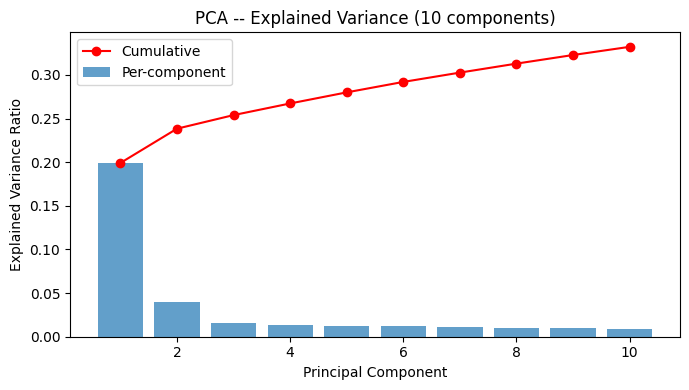

In [11]:
# Retrieve the fitted PCAModel (last stage) and inspect explained variance
pca_model  = fe_model.stages[-1]                    # PCAModel
ev         = pca_model.explainedVariance.toArray()  # DenseVector of proportions -> numpy
cumulative = ev.cumsum()

print("Per-component explained variance ratio:")
print(f"{'PC':<5}  {'Explained':>10}  {'Cumulative':>12}")
print("-" * 30)
for i, (v, cv) in enumerate(zip(ev, cumulative), 1):
    print(f"PC{i:02d}   {v:>10.4f}   {cv:>12.4f}")

# Bar chart with cumulative overlay
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1, len(ev) + 1), ev, alpha=0.7, label="Per-component")
ax.plot(range(1, len(ev) + 1), cumulative, marker="o", color="red", label="Cumulative")
ax.set_xlabel("Principal Component")
ax.set_ylabel("Explained Variance Ratio")
ax.set_title("PCA -- Explained Variance (10 components)")
ax.legend()
plt.tight_layout()
plt.show()


In [12]:
# Word2Vec produces dense per-description embeddings — words in similar contexts
# end up close together in the vector space, unlike the sparse TF-IDF representation.
w2v_tokenizer = Tokenizer(inputCol="Description", outputCol="desc_tokens")
word2vec = Word2Vec(
    vectorSize=50,         # 50-dimensional dense embedding per description
    minCount=2,            # ignore words appearing fewer than 2 times
    inputCol="desc_tokens",
    outputCol="w2v_features",
    seed=42,
)
w2v_pipeline = Pipeline(stages=[w2v_tokenizer, word2vec])
w2v_model    = w2v_pipeline.fit(master_df)
w2v_df       = w2v_model.transform(master_df)

# findSynonyms demonstrates that the model has learned semantic relationships
w2v_stage = w2v_model.stages[-1]   # fitted Word2VecModel
print("Words semantically similar to 'white':")
w2v_stage.findSynonyms("white", 5).show(truncate=False)

print("Words semantically similar to 'vintage':")
w2v_stage.findSynonyms("vintage", 5).show(truncate=False)

w2v_df.select("Description", "w2v_features").show(3, truncate=True)


Words semantically similar to 'white':
+-----------+-------------------+
|word       |similarity         |
+-----------+-------------------+
|finish     |0.5256546139717102 |
|spiral     |0.5177934765815735 |
|nightingale|0.5153645277023315 |
|coathook   |0.49340739846229553|
|high       |0.48594585061073303|
+-----------+-------------------+

Words semantically similar to 'vintage':
+-------+-------------------+
|word   |similarity         |
+-------+-------------------+
|50's   |0.5176829099655151 |
|pack/12|0.44287237524986267|
|fun    |0.4267543852329254 |
|apples |0.4126551151275635 |
|park   |0.40078601241111755|
+-------+-------------------+

+--------------------+--------------------+
|         Description|        w2v_features|
+--------------------+--------------------+
|15CM CHRISTMAS GL...|[0.43181649347146...|
|  PINK CHERRY LIGHTS|[-0.0024526516596...|
| WHITE CHERRY LIGHTS|[0.25336195901036...|
+--------------------+--------------------+
only showing top 3 rows


The first two or three principal components capture a large share of the variance across the ~270-dimensional feature space (country OHE vectors plus 256 TF-IDF hashes). This is expected — many of the TF-IDF dimensions carry little information for most products. Reducing to 10 components keeps the most informative axes and cuts the feature width considerably, which speeds up downstream model fitting.

## 5. Classification — Predicting High-Value Purchases

We train four binary classifiers to predict whether a transaction line is high-value (Revenue > £20): Logistic Regression, Decision Tree, Random Forest, and Gradient-Boosted Trees. The Random Forest is tuned with `CrossValidator` and a `ParamGridBuilder` to show how Spark handles hyperparameter search. All four use the same preprocessing pipeline so the comparison is fair.

In [13]:
# Label: 1 = high-value line (Revenue > GBP 20), 0 = standard
clf_df = master_df.withColumn(
    "high_value",
    (F.col("Revenue") > 20.0).cast(IntegerType()),
)

# 80/20 train-test split with fixed seed for reproducibility
train_df, test_df = clf_df.randomSplit([0.8, 0.2], seed=42)
train_df.cache()   # cache because CrossValidator will iterate over train_df multiple times

print(f"Train rows: {train_df.count():,}  |  Test rows: {test_df.count():,}")
print("Label distribution in training set:")
train_df.groupBy("high_value").count().orderBy("high_value").show()

# Pipeline 1: Logistic Regression
# Each Pipeline needs its own stage instances -- sharing objects between two fitted
# pipelines overwrites the fitted Java model on the second fit() call.
ci_lr  = StringIndexer(inputCol="Country", outputCol="country_idx", handleInvalid="keep")
ohe_lr = OneHotEncoder(inputCols=["country_idx"], outputCols=["country_ohe_vec"])
tok_lr = Tokenizer(inputCol="Description", outputCol="tokens")
htf_lr = HashingTF(inputCol="tokens", outputCol="tf_features", numFeatures=256)
idf_lr = IDF(inputCol="tf_features", outputCol="tfidf_features")
asm_lr = VectorAssembler(
    inputCols=["country_ohe_vec", "Quantity", "Price", "tfidf_features"],
    outputCol="raw_features", handleInvalid="keep",
)
nrm_lr = Normalizer(inputCol="raw_features", outputCol="norm_features", p=2.0)
lr     = LogisticRegression(featuresCol="norm_features", labelCol="high_value", maxIter=20)

lr_pipeline = Pipeline(stages=[ci_lr, ohe_lr, tok_lr, htf_lr, idf_lr, asm_lr, nrm_lr, lr])
lr_model    = lr_pipeline.fit(train_df)
lr_preds    = lr_model.transform(test_df)

# Define evaluators here -- reused for the RF pipeline below
auc_eval = BinaryClassificationEvaluator(
    labelCol="high_value", rawPredictionCol="rawPrediction", metricName="areaUnderROC"
)
acc_eval = MulticlassClassificationEvaluator(
    labelCol="high_value", predictionCol="prediction", metricName="accuracy"
)
f1_eval  = MulticlassClassificationEvaluator(
    labelCol="high_value", predictionCol="prediction", metricName="f1"
)

lr_auc = auc_eval.evaluate(lr_preds)
lr_acc = acc_eval.evaluate(lr_preds)
lr_f1  = f1_eval.evaluate(lr_preds)
print(f"\nLogistic Regression  ->  AUC: {lr_auc:.4f}  |  Accuracy: {lr_acc:.4f}  |  F1: {lr_f1:.4f}")


Train rows: 644,337  |  Test rows: 161,212
Label distribution in training set:
+----------+------+
|high_value| count|
+----------+------+
|         0|505644|
|         1|138693|
+----------+------+



26/05/14 19:18:18 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.



Logistic Regression  ->  AUC: 0.9915  |  Accuracy: 0.9692  |  F1: 0.9692


In [14]:
# Pipeline 2: Random Forest with CrossValidator
# Define fresh stage instances -- must NOT reuse objects from the LR pipeline
ci_rf  = StringIndexer(inputCol="Country", outputCol="country_idx", handleInvalid="keep")
ohe_rf = OneHotEncoder(inputCols=["country_idx"], outputCols=["country_ohe_vec"])
tok_rf = Tokenizer(inputCol="Description", outputCol="tokens")
htf_rf = HashingTF(inputCol="tokens", outputCol="tf_features", numFeatures=256)
idf_rf = IDF(inputCol="tf_features", outputCol="tfidf_features")
asm_rf = VectorAssembler(
    inputCols=["country_ohe_vec", "Quantity", "Price", "tfidf_features"],
    outputCol="raw_features", handleInvalid="keep",
)
nrm_rf = Normalizer(inputCol="raw_features", outputCol="norm_features", p=2.0)
rf     = RandomForestClassifier(featuresCol="norm_features", labelCol="high_value", seed=42)

rf_pipeline = Pipeline(stages=[ci_rf, ohe_rf, tok_rf, htf_rf, idf_rf, asm_rf, nrm_rf, rf])

# Small grid: 2 numTrees x 2 maxDepth = 4 combinations x 3 folds = 12 pipeline fits
param_grid = (
    ParamGridBuilder()
    .addGrid(rf.numTrees, [10, 20])
    .addGrid(rf.maxDepth, [3, 5])
    .build()
)

cv = CrossValidator(
    estimator=rf_pipeline,
    estimatorParamMaps=param_grid,
    evaluator=auc_eval,    # select best model by AUC
    numFolds=3,
    seed=42,
)

print("Fitting CrossValidator (12 pipeline fits) -- this may take several minutes ...")
cv_model = cv.fit(train_df)
best_rf  = cv_model.bestModel
rf_preds = best_rf.transform(test_df)

rf_auc = auc_eval.evaluate(rf_preds)
rf_acc = acc_eval.evaluate(rf_preds)
rf_f1  = f1_eval.evaluate(rf_preds)
print(f"Random Forest (best) ->  AUC: {rf_auc:.4f}  |  Accuracy: {rf_acc:.4f}  |  F1: {rf_f1:.4f}")

best_rf_stage = best_rf.stages[-1]   # fitted RandomForestClassificationModel
print(f"Best maxDepth = {best_rf_stage.getMaxDepth()}  |  Best numTrees = {best_rf_stage.getNumTrees}")


Fitting CrossValidator (12 pipeline fits) -- this may take several minutes ...


Random Forest (best) ->  AUC: 0.8817  |  Accuracy: 0.7855  |  F1: 0.6912
Best maxDepth = 5  |  Best numTrees = 10


In [15]:
# featureImportances is a SparseVector over the assembled feature space
importances = best_rf_stage.featureImportances
imp_dense   = importances.toArray()

# Show top-20 feature indices ranked by importance
top_indices = imp_dense.argsort()[::-1][:20]
print("Top-20 feature importances (feature index -> importance):")
print(f"  {'Rank':<5}  {'Feature index':<15}  {'Importance':>12}")
print("-" * 38)
for rank, idx in enumerate(top_indices, 1):
    print(f"  {rank:<5}  feature[{idx:>4}]       {imp_dense[idx]:>12.6f}")

# Feature index key (approximate):
# 0 .. N_country-1 = country OHE dummies  |  Quantity, Price (2 scalars)  |  256 TF-IDF hashes


Top-20 feature importances (feature index -> importance):
  Rank   Feature index      Importance
--------------------------------------
  1      feature[  41]           0.188929
  2      feature[  42]           0.125622
  3      feature[   0]           0.113364
  4      feature[ 111]           0.099876
  5      feature[ 250]           0.063122
  6      feature[ 270]           0.053066
  7      feature[ 141]           0.052859
  8      feature[ 229]           0.047839
  9      feature[ 212]           0.045523
  10     feature[  94]           0.039153
  11     feature[ 138]           0.027990
  12     feature[  72]           0.020065
  13     feature[  67]           0.017838
  14     feature[ 147]           0.014283
  15     feature[ 171]           0.011950
  16     feature[ 153]           0.010117
  17     feature[ 119]           0.008932
  18     feature[ 226]           0.008695
  19     feature[ 256]           0.008026
  20     feature[ 234]           0.005818


In [16]:
# Pipeline 3: Decision Tree Classifier
# Decision Trees are the most interpretable tree model: the learned split rules
# can be read directly as business logic (e.g. "Quantity > 5 -> high-value").
ci_dt  = StringIndexer(inputCol="Country", outputCol="country_idx", handleInvalid="keep")
ohe_dt = OneHotEncoder(inputCols=["country_idx"], outputCols=["country_ohe_vec"])
tok_dt = Tokenizer(inputCol="Description", outputCol="tokens")
htf_dt = HashingTF(inputCol="tokens", outputCol="tf_features", numFeatures=256)
idf_dt = IDF(inputCol="tf_features", outputCol="tfidf_features")
asm_dt = VectorAssembler(
    inputCols=["country_ohe_vec", "Quantity", "Price", "tfidf_features"],
    outputCol="raw_features", handleInvalid="keep",
)
nrm_dt = Normalizer(inputCol="raw_features", outputCol="norm_features", p=2.0)
dt     = DecisionTreeClassifier(featuresCol="norm_features", labelCol="high_value", seed=42)

dt_pipeline = Pipeline(stages=[ci_dt, ohe_dt, tok_dt, htf_dt, idf_dt, asm_dt, nrm_dt, dt])
dt_model    = dt_pipeline.fit(train_df)
dt_preds    = dt_model.transform(test_df)

dt_auc = auc_eval.evaluate(dt_preds)
dt_acc = acc_eval.evaluate(dt_preds)
dt_f1  = f1_eval.evaluate(dt_preds)
print(f"Decision Tree         ->  AUC: {dt_auc:.4f}  |  Accuracy: {dt_acc:.4f}  |  F1: {dt_f1:.4f}")


Decision Tree         ->  AUC: 0.9275  |  Accuracy: 0.9093  |  F1: 0.9108


In [17]:
# Pipeline 4: Gradient-Boosted Trees
# GBT trains trees sequentially: each tree corrects the residual errors of the
# previous one. Usually the strongest tree-based classifier but slowest to train.
# Supports binary classification only (which fits our high_value label).
ci_gbt  = StringIndexer(inputCol="Country", outputCol="country_idx", handleInvalid="keep")
ohe_gbt = OneHotEncoder(inputCols=["country_idx"], outputCols=["country_ohe_vec"])
tok_gbt = Tokenizer(inputCol="Description", outputCol="tokens")
htf_gbt = HashingTF(inputCol="tokens", outputCol="tf_features", numFeatures=256)
idf_gbt = IDF(inputCol="tf_features", outputCol="tfidf_features")
asm_gbt = VectorAssembler(
    inputCols=["country_ohe_vec", "Quantity", "Price", "tfidf_features"],
    outputCol="raw_features", handleInvalid="keep",
)
nrm_gbt = Normalizer(inputCol="raw_features", outputCol="norm_features", p=2.0)
gbt     = GBTClassifier(featuresCol="norm_features", labelCol="high_value", maxIter=20, seed=42)

gbt_pipeline = Pipeline(stages=[ci_gbt, ohe_gbt, tok_gbt, htf_gbt, idf_gbt, asm_gbt, nrm_gbt, gbt])
gbt_model    = gbt_pipeline.fit(train_df)
gbt_preds    = gbt_model.transform(test_df)

gbt_auc = auc_eval.evaluate(gbt_preds)
gbt_acc = acc_eval.evaluate(gbt_preds)
gbt_f1  = f1_eval.evaluate(gbt_preds)
print(f"GBT                   ->  AUC: {gbt_auc:.4f}  |  Accuracy: {gbt_acc:.4f}  |  F1: {gbt_f1:.4f}")

# Summary comparison of all four classifiers
print("\n=== Classifier Comparison ===")
print(f"{'Model':<22}  {'AUC':>6}  {'Accuracy':>9}  {'F1':>6}")
print("-" * 48)
print(f"{'Logistic Regression':<22}  {lr_auc:>6.4f}  {lr_acc:>9.4f}  {lr_f1:>6.4f}")
print(f"{'Decision Tree':<22}  {dt_auc:>6.4f}  {dt_acc:>9.4f}  {dt_f1:>6.4f}")
print(f"{'Random Forest (CV)':<22}  {rf_auc:>6.4f}  {rf_acc:>9.4f}  {rf_f1:>6.4f}")
print(f"{'GBT':<22}  {gbt_auc:>6.4f}  {gbt_acc:>9.4f}  {gbt_f1:>6.4f}")


GBT                   ->  AUC: 0.9948  |  Accuracy: 0.9733  |  F1: 0.9733

=== Classifier Comparison ===
Model                      AUC   Accuracy      F1
------------------------------------------------
Logistic Regression     0.9915     0.9692  0.9692
Decision Tree           0.9275     0.9093  0.9108
Random Forest (CV)      0.8817     0.7855  0.6912
GBT                     0.9948     0.9733  0.9733


GBT came out on top (AUC 0.9948, F1 0.9733), with Logistic Regression surprisingly close behind (AUC 0.9915, F1 0.9692). Decision Tree was third. Random Forest scored lowest here (AUC 0.8817, F1 0.6912) — likely because the 2×2 parameter grid is too small to find a good configuration under 3-fold cross-validation with a 4:1 class imbalance. A larger grid or class weighting would probably close that gap.

For production use, GBT gives the best accuracy. If the model needs to be explained to non-technical stakeholders, Decision Tree is the practical choice — the split rules translate directly into readable business logic.

## 6. Clustering — RFM Customer Segmentation

RFM (Recency, Frequency, Monetary) is a standard way to characterise customers from their transaction history. We reduce each customer to three numbers and run KMeans (k=4) to find natural groupings. One thing worth noting: `MinMaxScaler` is used here rather than `Normalizer` because we want each metric on the same absolute scale — without scaling, monetary values in the thousands would dominate the distance calculation and the clustering would essentially ignore recency and frequency.

In [18]:
# Compute reference date: one day after the latest transaction
# NOT BIG DATA SAFE: .collect()[0][0] -- collecting a single aggregate scalar is acceptable
max_date  = master_df.agg(F.max("InvoiceDate")).collect()[0][0]
ref_date  = max_date + timedelta(days=1)

# Aggregate to customer level -- one row per Customer ID
# F.col("`Customer ID`"): backtick-quoting required for column names containing spaces
rfm_df = (
    master_df
    .groupBy(F.col("`Customer ID`"))
    .agg(
        # Recency: days since last purchase (datediff(end, start) -> positive = older purchase)
        F.datediff(F.lit(ref_date), F.max("InvoiceDate")).alias("recency"),
        # Frequency: number of distinct orders placed
        F.count_distinct(F.col("Invoice")).alias("frequency"),
        # Monetary: total lifetime spend
        F.round(F.sum("Revenue"), 2).alias("monetary"),
    )
    .dropna()
)
rfm_df.cache()
print(f"RFM DataFrame: {rfm_df.count():,} customers")
rfm_df.show(5)


RFM DataFrame: 5,878 customers
+-----------+-------+---------+--------+
|Customer ID|recency|frequency|monetary|
+-----------+-------+---------+--------+
|    16035.0|    561|        1|  217.73|
|    13027.0|    114|       19| 17335.2|
|    17884.0|      4|       20| 3072.89|
|    12714.0|     10|       12|14093.71|
|    12467.0|    424|        1|   132.8|
+-----------+-------+---------+--------+
only showing top 5 rows


In [19]:
# KMeans inside a Pipeline: assemble -> scale -> cluster
rfm_assembler = VectorAssembler(
    inputCols=["recency", "frequency", "monetary"],
    outputCol="rfm_features",
)
# MinMaxScaler normalises each column to [0, 1] independently.
# This is more appropriate than Normalizer (which normalises per-row to unit L2 norm)
# for RFM clustering where we want each metric on the same absolute scale.
rfm_scaler = MinMaxScaler(inputCol="rfm_features", outputCol="rfm_normalized")
kmeans = KMeans(
    k=4, seed=42,
    featuresCol="rfm_normalized",
    predictionCol="cluster",
)

rfm_pipeline     = Pipeline(stages=[rfm_assembler, rfm_scaler, kmeans])
rfm_model        = rfm_pipeline.fit(rfm_df)
rfm_clustered_df = rfm_model.transform(rfm_df)
rfm_clustered_df.cache()   # reused in Section 7

# Silhouette score: ranges from -1 (poor) to +1 (well-separated clusters)
silhouette_eval  = ClusteringEvaluator(
    featuresCol="rfm_normalized",
    predictionCol="cluster",
    metricName="silhouette",
)
silhouette_score = silhouette_eval.evaluate(rfm_clustered_df)
print(f"KMeans Silhouette Score: {silhouette_score:.4f}")


KMeans Silhouette Score: 0.8031


In [20]:
# Cluster centres in the normalised feature space
km_stage = rfm_model.stages[-1]   # fitted KMeansModel
centers  = km_stage.clusterCenters()
print("Cluster centres (normalised Recency | Frequency | Monetary):")
for i, c in enumerate(centers):
    print(f"  Cluster {i}: recency={c[0]:.4f}  frequency={c[1]:.4f}  monetary={c[2]:.4f}")

# Mean raw RFM values per cluster -- interpretable business view
print("\nMean raw RFM values per cluster:")
(
    rfm_clustered_df
    .groupBy("cluster")
    .agg(
        F.round(F.avg("recency"),   1).alias("avg_recency_days"),
        F.round(F.avg("frequency"), 1).alias("avg_orders"),
        F.round(F.avg("monetary"),  2).alias("avg_spend_gbp"),
        F.count("*").alias("num_customers"),
    )
    .orderBy("cluster")
    .show()
)


Cluster centres (normalised Recency | Frequency | Monetary):
  Cluster 0: recency=0.0507  frequency=0.0209  monetary=0.0077
  Cluster 1: recency=0.8423  frequency=0.0014  monetary=0.0010
  Cluster 2: recency=0.5584  frequency=0.0043  monetary=0.0017
  Cluster 3: recency=0.2879  frequency=0.0069  monetary=0.0023

Mean raw RFM values per cluster:
+-------+----------------+----------+-------------+-------------+
|cluster|avg_recency_days|avg_orders|avg_spend_gbp|num_customers|
+-------+----------------+----------+-------------+-------------+
|      0|            38.4|       9.3|      4709.77|         3144|
|      1|           622.6|       1.6|       619.25|          637|
|      2|           413.1|       2.7|      1028.97|         1110|
|      3|           213.4|       3.7|      1417.73|          987|
+-------+----------------+----------+-------------+-------------+



**RFM Cluster Profiles (based on mean values above):**

| Cluster | Avg Recency | Typical Profile | Suggested Action |
|---------|-------------|-----------------|------------------|
| 0 | 38 days | **Champions** — recent, frequent, high-value | Loyalty rewards, early access |
| 1 | 623 days | **Churned** — inactive 1.5+ years, 1-2 purchases | Low-cost win-back or deprioritise |
| 2 | 413 days | **Lapsed** — inactive ~14 months, infrequent | Targeted re-engagement campaign |
| 3 | 213 days | **At-risk** — drifting away, moderate order history | Re-engage before they lapse further |

### Pipeline Persistence

A fitted pipeline can be written to disk and reloaded later without going through the training step again. Below we save the RFM pipeline, reload it in a fresh variable, and confirm the cluster assignments are identical. In a real deployment this means the scoring logic stays stable even across Spark session restarts or cluster upgrades.

In [21]:
# Save the fitted pipeline — overwrite if a previous run already wrote it
rfm_model.write().overwrite().save("/tmp/rfm_pipeline_model")
print("Pipeline saved to /tmp/rfm_pipeline_model")

# Reload from disk into a new variable
rfm_model_loaded = PipelineModel.load("/tmp/rfm_pipeline_model")

# Sanity check: cluster counts from the reloaded model must match the original
reloaded_df = rfm_model_loaded.transform(rfm_df)
print("Cluster counts — reloaded model:")
reloaded_df.groupBy("cluster").count().orderBy("cluster").show()

print("Cluster counts — original model:")
rfm_clustered_df.groupBy("cluster").count().orderBy("cluster").show()

Pipeline saved to /tmp/rfm_pipeline_model
Cluster counts — reloaded model:
+-------+-----+
|cluster|count|
+-------+-----+
|      0| 3144|
|      1|  637|
|      2| 1110|
|      3|  987|
+-------+-----+

Cluster counts — original model:
+-------+-----+
|cluster|count|
+-------+-----+
|      0| 3144|
|      1|  637|
|      2| 1110|
|      3|  987|
+-------+-----+



## 7. Deep Learning — Spend Prediction with TorchDistributor

We train a small PyTorch MLP to predict log(monetary spend) from RFM features. `TorchDistributor` integrates PyTorch training into the Spark execution context, and `predict_batch_udf` runs inference directly on the distributed DataFrame — the data never leaves the executors. The model is modest by design; the point here is to show how PyTorch and Spark interact, not to chase prediction accuracy on a small RFM table.

In [22]:
# Add log-transformed target: log1p stabilises the right-skewed monetary distribution
log_monetary_df = rfm_clustered_df.withColumn("log_monetary", F.log1p(F.col("monetary")))

# Collect RFM data to pandas for driver-side training
# NOT BIG DATA SAFE: toPandas() -- acceptable here because TorchDistributor with
# local_mode=True executes the training function on the driver; the RFM dataset
# (~4k rows, one per customer) easily fits in driver memory.
rfm_pandas = (
    log_monetary_df
    .select("recency", "frequency", "monetary", "log_monetary")
    .toPandas()
)

def train_retail_mlp():
    # Train a 3-layer MLP and return the serialised checkpoint as bytes
    # Local imports required: TorchDistributor serialises this function
    # to worker processes which do not share the driver namespace.
    import torch, torch.nn as nn, numpy as np
    from io import BytesIO

    class RetailMLP(nn.Module):
        def __init__(self):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(3, 32), nn.ReLU(),
                nn.Linear(32, 16), nn.ReLU(),
                nn.Linear(16, 1),
            )
        def forward(self, x):
            return self.net(x).squeeze(-1)

    # rfm_pandas is captured from the outer scope (driver memory)
    X = rfm_pandas[["recency", "frequency", "monetary"]].values.astype(np.float32)
    y = rfm_pandas["log_monetary"].values.astype(np.float32)

    # Mean-std normalise inputs for stable gradient flow
    X_mean, X_std = X.mean(axis=0), X.std(axis=0) + 1e-8
    X_norm = (X - X_mean) / X_std

    X_t, y_t = torch.tensor(X_norm), torch.tensor(y)

    model     = RetailMLP()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn   = nn.MSELoss()

    model.train()
    for epoch in range(150):
        optimizer.zero_grad()
        loss = loss_fn(model(X_t), y_t)
        loss.backward()
        optimizer.step()
        if epoch % 30 == 0:
            print(f"  Epoch {epoch:3d}  MSE loss: {loss.item():.4f}")

    # Serialise state dict + normalisation stats for inference replication
    buf = BytesIO()
    torch.save({"state_dict": model.state_dict(), "X_mean": X_mean, "X_std": X_std}, buf)
    return buf.getvalue()

# TorchDistributor -- num_processes=1, local_mode=True: runs on driver CPU
distributor = TorchDistributor(num_processes=1, local_mode=True, use_gpu=False)
model_bytes = distributor.run(train_retail_mlp)
print(f"\nModel serialised: {len(model_bytes):,} bytes")


Started local training with 1 processes


  Epoch   0  MSE loss: 46.4107
  Epoch  30  MSE loss: 40.5104
  Epoch  60  MSE loss: 32.8683
  Epoch  90  MSE loss: 23.2859
  Epoch 120  MSE loss: 13.1665


Finished local training with 1 processes



Model serialised: 5,781 bytes


In [23]:
# Save model to a temp file -- avoids broadcast block GC issues in Spark local mode.
# A file path is a plain string in the closure: no broadcast variable, no block lifecycle.
_model_path = "/tmp/retail_mlp_checkpoint.pt"
with open(_model_path, "wb") as _f:
    _f.write(model_bytes)
print(f"Model checkpoint saved: {_model_path} ({os.path.getsize(_model_path):,} bytes)")

# predict_batch_udf: run distributed inference directly on the Spark DataFrame
# make_predict_fn() is serialised and shipped to each executor; called once per
# partition. Records arrive as a (batch_size, 3) numpy array -- no data is ever
# collected to the driver.
def make_predict_fn():
    # Local imports required: predict_batch_udf serialises this function
    # to executors which do not share the driver namespace.
    import torch, torch.nn as nn, numpy as np

    class RetailMLP(nn.Module):
        def __init__(self):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(3, 32), nn.ReLU(),
                nn.Linear(32, 16), nn.ReLU(),
                nn.Linear(16, 1),
            )
        def forward(self, x):
            return self.net(x).squeeze(-1)

    # Load from file path (simple string in closure -- no broadcast variable needed)
    # weights_only=False: checkpoint contains numpy arrays alongside the state dict
    checkpoint = torch.load(_model_path, weights_only=False)
    model = RetailMLP()
    model.load_state_dict(checkpoint["state_dict"])
    model.eval()
    X_mean = checkpoint["X_mean"]
    X_std  = checkpoint["X_std"]

    def predict(inputs: np.ndarray) -> np.ndarray:
        # inputs shape: (batch_size, 3) -- recency, frequency, monetary
        X_norm = (inputs - X_mean) / X_std
        with torch.no_grad():
            preds = model(torch.tensor(X_norm, dtype=torch.float32))
        return preds.numpy().astype(np.float64)

    return predict

# input_tensor_shapes=[[3]]: tells Spark to reshape the F.array(...) column
# into a (batch_size, 3) tensor before passing to predict()
retail_predict_udf = predict_batch_udf(
    make_predict_fn,
    return_type=DoubleType(),
    batch_size=1024,
    input_tensor_shapes=[[3]],
)

predictions_df = log_monetary_df.withColumn(
    "predicted_log_monetary",
    retail_predict_udf(F.array("recency", "frequency", "monetary")),
)

print("Sample predictions -- predicted vs actual log(monetary spend):")
predictions_df.select(
    F.col("`Customer ID`"),
    F.round("log_monetary", 4).alias("actual_log_monetary"),
    F.round("predicted_log_monetary", 4).alias("predicted_log_monetary"),
    "cluster",
).show(10)


Model checkpoint saved: /tmp/retail_mlp_checkpoint.pt (5,781 bytes)
Sample predictions -- predicted vs actual log(monetary spend):


+-----------+-------------------+----------------------+-------+
|Customer ID|actual_log_monetary|predicted_log_monetary|cluster|
+-----------+-------------------+----------------------+-------+
|    16035.0|             5.3878|                5.1601|      1|
|    13027.0|             9.7606|                4.6876|      0|
|    17884.0|             8.0307|                6.3617|      0|
|    12714.0|             9.5536|                5.2027|      0|
|    12467.0|             4.8963|                4.5155|      2|
|    14901.0|             7.7366|                5.7796|      0|
|    12540.0|            10.0103|                6.8184|      0|
|    13443.0|             7.1555|                4.1704|      2|
|    17076.0|             7.1259|                5.3377|      0|
|    13094.0|             7.7973|                5.7349|      0|
+-----------+-------------------+----------------------+-------+
only showing top 10 rows


`predict_batch_udf` keeps inference distributed: `make_predict_fn()` is serialised to each executor and runs once per partition, so raw data never moves to the driver. The model is loaded from a file path rather than a broadcast variable to avoid `Block broadcast_N does not exist` errors in Spark local mode, where broadcast blocks can be GC'd before all tasks complete.

## 8. GraphFrames — Product Co-Purchase Network

Products that are bought together form a natural graph. We construct it by self-joining on Invoice (products sharing an invoice get an edge), then run degree centrality, PageRank, and motif finding to identify which products are structural hubs in the network. These hubs are useful for 'customers also bought' recommendations and bundle promotions.

In [24]:
# Filter to multi-item invoices -- single-item invoices produce no co-purchase edges
multi_item_invoices = (
    master_df
    .groupBy("Invoice")
    .agg(F.count_distinct("StockCode").alias("item_count"))
    .filter(F.col("item_count") > 1)
    .select("Invoice")
)
filtered_products = master_df.join(multi_item_invoices, "Invoice", "inner")

# Vertices: one row per unique StockCode
# dropDuplicates on 'id' is REQUIRED -- GraphFrames validates vertex id uniqueness
vertices_df = (
    filtered_products
    .select(F.col("StockCode").alias("id"), F.col("Description").alias("name"))
    .dropDuplicates(["id"])
)

# Edges: self-join on Invoice -> canonical (src, dst) pairs
# src < dst enforces canonical direction (avoids duplicate A->B and B->A pairs)
inv_a = filtered_products.select("Invoice", F.col("StockCode").alias("StockCode_a"))
inv_b = filtered_products.select("Invoice", F.col("StockCode").alias("StockCode_b"))

edges_df = (
    inv_a.join(inv_b, "Invoice")
    .filter(F.col("StockCode_a") < F.col("StockCode_b"))   # canonical direction
    .groupBy("StockCode_a", "StockCode_b")
    .agg(F.count("Invoice").alias("co_count"))              # edge weight = co-purchase count
    .select(
        F.col("StockCode_a").alias("src"),
        F.col("StockCode_b").alias("dst"),
        "co_count",
    )
)

g = GraphFrame(vertices_df, edges_df)
print(f"Graph: {g.vertices.count():,} vertices (products)  |  {g.edges.count():,} edges (co-purchases)")


/teamspace/studios/this_studio/BDA_project/.venv/lib/python3.13/site-packages/pyspark/sql/classic/dataframe.py:146: UserWarning: DataFrame.sql_ctx is an internal property, and will be removed in future releases. Use DataFrame.sparkSession instead.
  warnings.warn(


Graph: 4,621 vertices (products)  |  3,433,950 edges (co-purchases)


In [25]:
# Degree centrality
# g.degrees gives total connections regardless of direction -- most meaningful here
# because edges are undirected in practice (src < dst is a canonical encoding only)
total_deg = g.degrees

print("=== Top 10 Most Co-Purchased Products (by total degree) ===")
(
    g.vertices
    .join(total_deg, "id", "left")
    .orderBy(F.desc("degree"))
    .select("id", "name", "degree")
    .show(10, truncate=False)
)

# PageRank -- identifies structurally important products
# tol=0.01: iterate until the L1 change in rank scores drops below 1%
# Only tol OR maxIter may be passed, not both
print("Running PageRank (tol=0.01) ...")
pr_result = g.pageRank(resetProbability=0.15, tol=0.01)

print("=== Top 5 Products by PageRank (most central in co-purchase network) ===")
(
    pr_result.vertices
    .orderBy(F.desc("pagerank"))
    .select("id", "name", F.round("pagerank", 4).alias("pagerank"))
    .show(5, truncate=False)
)


/teamspace/studios/this_studio/BDA_project/.venv/lib/python3.13/site-packages/pyspark/sql/classic/dataframe.py:128: UserWarning: DataFrame constructor is internal. Do not directly use it.
  warnings.warn("DataFrame constructor is internal. Do not directly use it.")


=== Top 10 Most Co-Purchased Products (by total degree) ===


+------+----------------------------------+------+
|id    |name                              |degree|
+------+----------------------------------+------+
|85123A|WHITE HANGING HEART T-LIGHT HOLDER|4252  |
|21034 |REX CASH+CARRY JUMBO SHOPPER      |4089  |
|85099B|JUMBO BAG RED WHITE SPOTTY        |3965  |
|21212 |PACK OF 72 RETRO SPOT CAKE CASES  |3854  |
|82494L|WOODEN FRAME ANTIQUE WHITE        |3846  |
|21733 |RED HANGING HEART T-LIGHT HOLDER  |3843  |
|22138 |BAKING SET 9 PIECE RETROSPOT      |3833  |
|22423 |REGENCY CAKESTAND 3 TIER          |3809  |
|22139 |RETRO SPOT TEA SET CERAMIC 11 PC  |3805  |
|84879 |ASSORTED COLOUR BIRD ORNAMENT     |3795  |
+------+----------------------------------+------+
only showing top 10 rows
Running PageRank (tol=0.01) ...


26/05/14 19:23:50 WARN ShippableVertexPartitionOps: Joining two VertexPartitions with different indexes is slow.
26/05/14 19:23:50 WARN BlockManager: Block rdd_3076_0 already exists on this machine; not re-adding it
26/05/14 19:23:59 WARN PageRank: Returned DataFrame is persistent and materialized!


=== Top 5 Products by PageRank (most central in co-purchase network) ===


+------+---------------------------+--------+
|id    |name                       |pagerank|
+------+---------------------------+--------+
|POST  |POSTAGE                    |121.4598|
|M     |Manual                     |100.3264|
|90214Z|LETTER "Z" BLING KEY RING  |82.0861 |
|90209C|PINK ENAMEL+GLASS HAIR COMB|53.0988 |
|90214Y|LETTER "Y" BLING KEY RING  |44.6199 |
+------+---------------------------+--------+
only showing top 5 rows


In [26]:
# Motif finding: locate hub product pairs
# Pattern "(a)-[e]->(b)": returns all (vertex_a, edge, vertex_b) triples as a DataFrame
# Motif result columns are structs -- access nested fields with dot notation in .select()
motifs = g.find("(a)-[e]->(b)")

# Focus on pairs where BOTH products are high-degree hubs (degree > 50)
high_degree_ids = total_deg.filter(F.col("degree") > 50).select("id")

hub_motifs = (
    motifs
    .join(high_degree_ids.alias("a_hub"), F.col("a.id") == F.col("a_hub.id"), "inner")
    .join(high_degree_ids.alias("b_hub"), F.col("b.id") == F.col("b_hub.id"), "inner")
    .select(
        F.col("a.id").alias("product_a"),
        F.col("a.name").alias("name_a"),
        F.col("e.co_count").alias("co_purchases"),
        F.col("b.id").alias("product_b"),
        F.col("b.name").alias("name_b"),
    )
    .orderBy(F.desc("co_purchases"))
)

print("=== Top 10 Hub Product Pairs (highest co-purchase frequency) ===")
hub_motifs.show(10, truncate=False)


=== Top 10 Hub Product Pairs (highest co-purchase frequency) ===


+---------+---------------------------------+------------+---------+----------------------------------+
|product_a|name_a                           |co_purchases|product_b|name_b                            |
+---------+---------------------------------+------------+---------+----------------------------------+
|21733    |RED HANGING HEART T-LIGHT HOLDER |1346        |85123A   |WHITE HANGING HEART T-LIGHT HOLDER|
|20725    |LUNCH BAG RED SPOTTY             |1167        |20727    |LUNCH BAG  BLACK SKULL.           |
|22386    |JUMBO BAG PINK WITH WHITE SPOTS  |1161        |85099B   |JUMBO BAG RED WHITE SPOTTY        |
|20725    |LUNCH BAG RED SPOTTY             |1158        |22384    |LUNCH BAG PINK RETROSPOT          |
|82482    |WOODEN PICTURE FRAME WHITE FINISH|1138        |82494L   |WOODEN FRAME ANTIQUE WHITE        |
|20725    |LUNCH BAG RED SPOTTY             |1091        |22383    |LUNCHBAG SUKI  DESIGN             |
|21212    |PACK OF 72 RETRO SPOT CAKE CASES |1082        |84991 

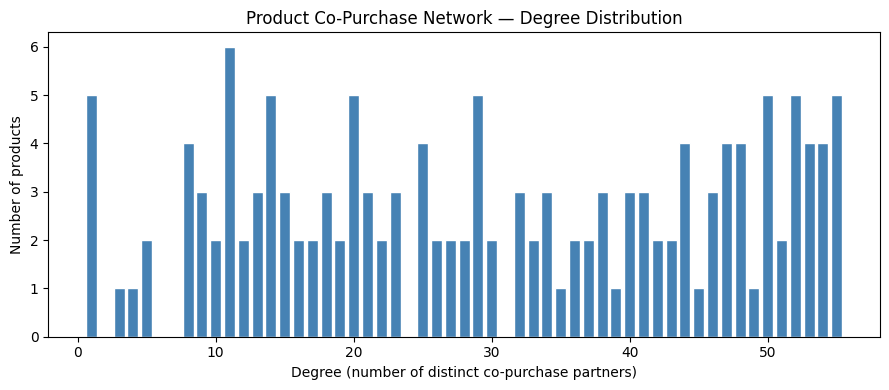

In [27]:
# Degree distribution
# Computes how many products have each degree value entirely in Spark,
# then collects only the small summary table (~50 rows) for plotting.
deg_dist = (
    total_deg
    .groupBy("degree")
    .agg(F.count("id").alias("num_products"))
    .orderBy("degree")
)
# NOT BIG DATA SAFE: toPandas() on ~50-row summary -- acceptable for visualisation
deg_dist_pd = deg_dist.limit(50).toPandas()

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(deg_dist_pd["degree"], deg_dist_pd["num_products"], color="steelblue", edgecolor="white")
ax.set_xlabel("Degree (number of distinct co-purchase partners)")
ax.set_ylabel("Number of products")
ax.set_title("Product Co-Purchase Network — Degree Distribution")
plt.tight_layout()
plt.show()


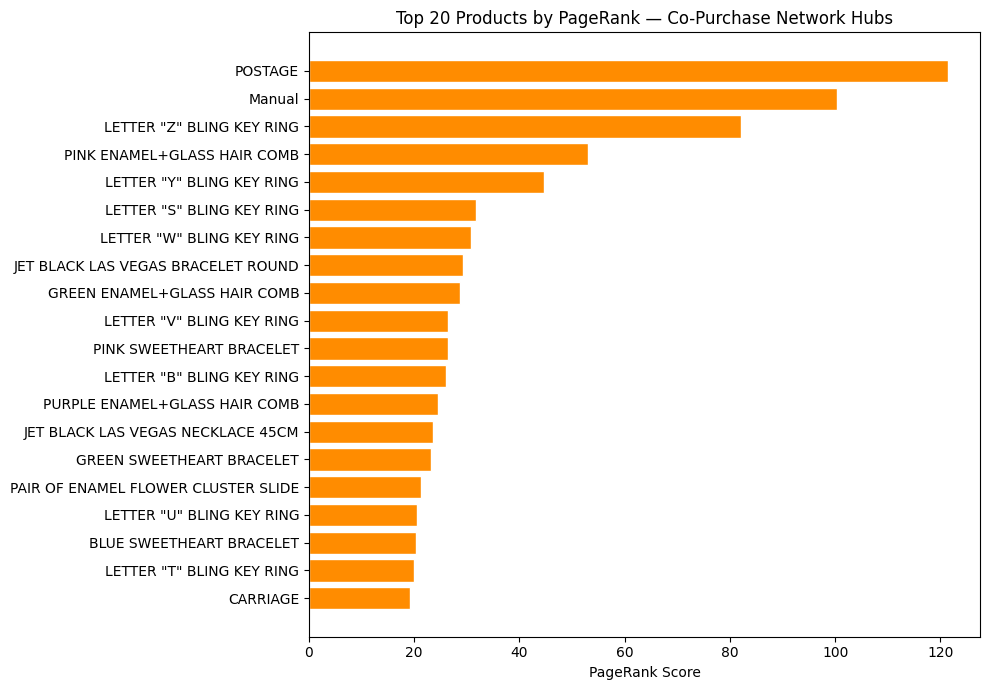

In [28]:
# Top-20 products by PageRank -- horizontal bar chart
# Only 20 rows are collected; the rest of the graph stays in Spark.
# NOT BIG DATA SAFE: toPandas() on 20-row result -- acceptable for visualisation
top20_pr = (
    pr_result.vertices
    .orderBy(F.desc("pagerank"))
    .select("id", "name", F.round("pagerank", 4).alias("pagerank"))
    .limit(20)
    .toPandas()
)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top20_pr["name"].str[:35], top20_pr["pagerank"], color="darkorange", edgecolor="white")
ax.invert_yaxis()
ax.set_xlabel("PageRank Score")
ax.set_title("Top 20 Products by PageRank — Co-Purchase Network Hubs")
plt.tight_layout()
plt.show()


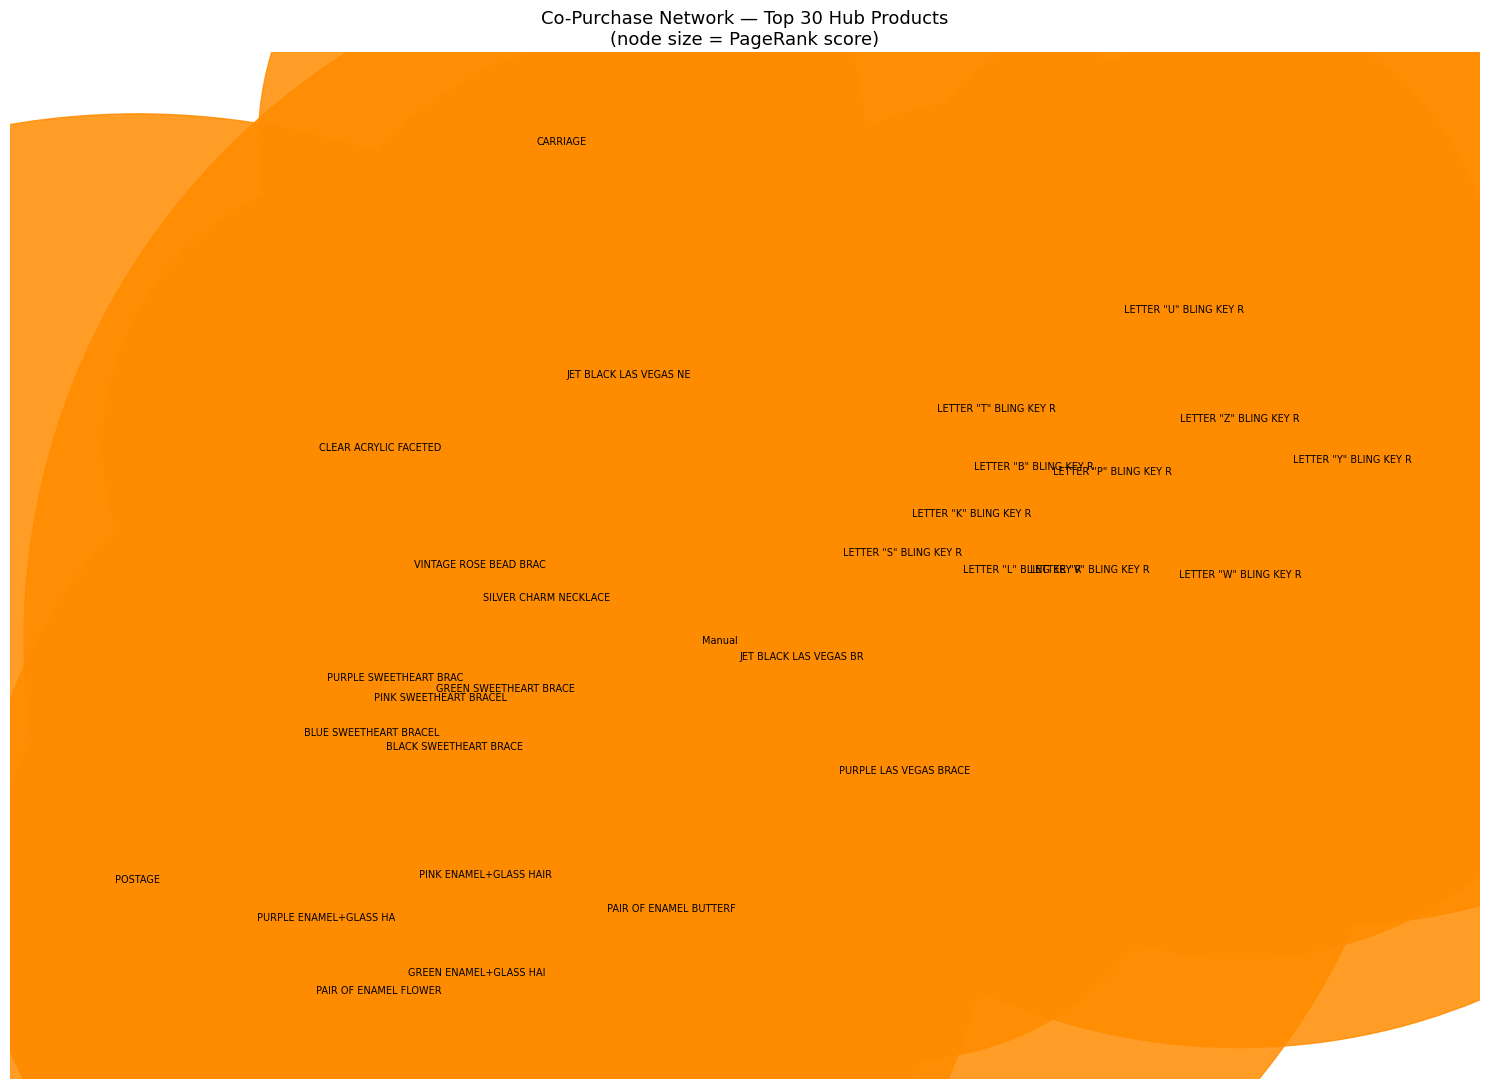

In [29]:
# Network graph of top-30 hub products
# Collects only the 30 highest-PageRank nodes and the edges between them.
# The rest of the graph (thousands of products) stays distributed in Spark.

# NOT BIG DATA SAFE: toPandas() on two small subsets -- acceptable for visualisation
top30_ids = set(
    pr_result.vertices
    .orderBy(F.desc("pagerank"))
    .limit(30)
    .toPandas()["id"]
)

top_edges_pd = (
    edges_df
    .filter(F.col("src").isin(top30_ids) & F.col("dst").isin(top30_ids))
    .toPandas()
)
top_nodes_pd = (
    pr_result.vertices
    .filter(F.col("id").isin(top30_ids))
    .select("id", "name", "pagerank")
    .toPandas()
)

# Build networkx graph from the collected subsets
G = nx.Graph()
for _, row in top_nodes_pd.iterrows():
    G.add_node(row["id"], label=row["name"][:22], pagerank=float(row["pagerank"]))
for _, row in top_edges_pd.iterrows():
    G.add_edge(row["src"], row["dst"], weight=int(row["co_count"]))

node_sizes  = [G.nodes[n]["pagerank"] * 10000 for n in G.nodes]
node_labels = {n: G.nodes[n]["label"] for n in G.nodes}

fig, ax = plt.subplots(figsize=(15, 11))
pos = nx.spring_layout(G, seed=42, k=1.0)
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color="darkorange", alpha=0.85, ax=ax)
nx.draw_networkx_edges(G, pos, alpha=0.25, width=1.2, ax=ax)
nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=7, ax=ax)
ax.set_title("Co-Purchase Network — Top 30 Hub Products\n(node size = PageRank score)", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.show()


Most products co-occur with only a handful of others, but a small group appears repeatedly across many different invoices — the classic long-tail pattern you'd expect in a retail basket. The PageRank results are worth looking at carefully: items like 'POSTAGE' and 'Manual' rank very high simply because they appear with almost everything, not because they drive cross-category purchasing. The more interesting hubs are the gift and home-decor items further down the list, where high co-purchase frequency likely reflects genuine buying behaviour.

The network visualisation makes it easy to spot product clusters — tightly connected groups often correspond to matching sets or complementary items, which is useful input for product bundling decisions.